In [9]:
import torch

file_path = "/mnt/abka03/Projects/xl-vlms/outputs/run_test_tiger_qwen7b/concept/snmf/combined_concept_snmf_raw.pth"
data1 = torch.load(file_path, map_location='cpu')
print(data1.keys())
print(data1['concepts'].shape)
print(data1['image_grounding_bboxes'])
print(data1['image_grounding_predictions'])
print(data1['text_grounding'])
print(data1['image_grounding_paths'])
print(data1['concept_names'])

dict_keys(['concepts', 'concept_names', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'image_grounding_bboxes', 'image_grounding_masks', 'analysis_model', 'image_grounding_predictions'])
torch.Size([6, 3584])
[[[42, 42, 164, 164], [49, 49, 164, 164], [49, 49, 164, 164], [49, 49, 164, 164], [49, 49, 164, 164]], [[48, 48, 164, 164], [49, 49, 164, 164], [49, 49, 164, 164], [78, 78, 164, 164], [49, 49, 164, 164]], [[42, 42, 164, 164], [42, 42, 164, 164], [49, 49, 164, 164], [46, 46, 164, 164], [42, 42, 164, 164]], [[42, 42, 164, 164], [49, 49, 164, 164], [49, 49, 164, 164], [42, 42, 164, 164], [64, 64, 164, 164]], [[49, 49, 164, 164], [44, 44, 164, 164], [49, 49, 164, 164], [49, 49, 164, 164], [46, 46, 164, 164]], [[106, 106, 164, 164], [78, 78, 164, 164], [79, 79, 164, 164], [102, 102, 164, 164], [88, 88, 164, 164]]]
[['Fur', 'Fur', 'Fur', 'Fur', 'Fur'], ['Gras', 'gras', 'Gras', 'Gras', 'Gras'], ['stripe', 'stripe', 'Stripe', 'Stripe', 'Stripe'], ['t', 

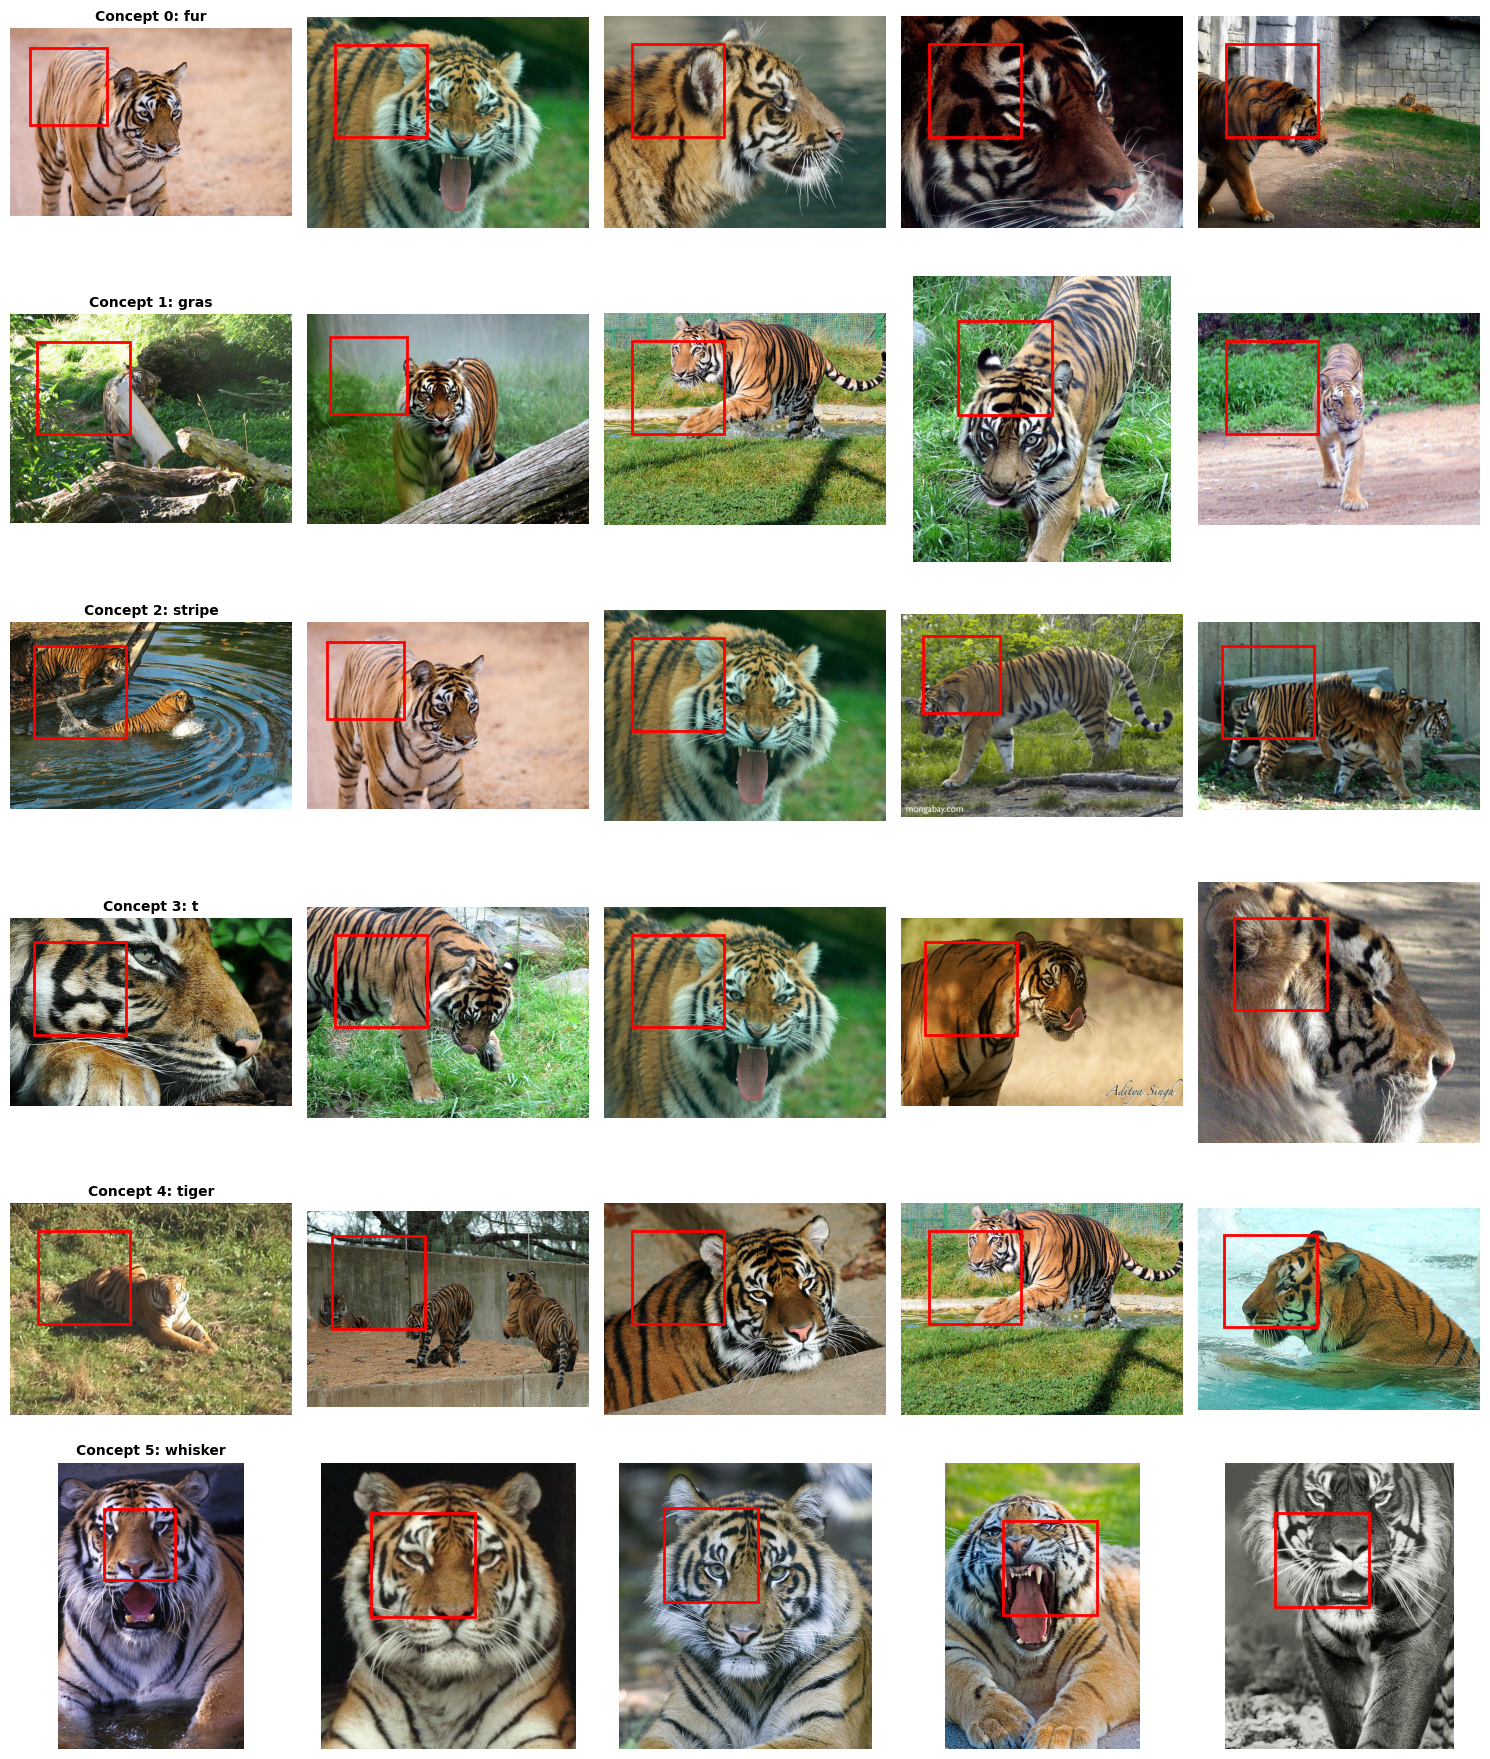

In [10]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

# Expected keys in data1:
# - image_grounding_paths: [num_concepts][num_images]
# - image_grounding_bboxes: [num_concepts][num_images] with [x, y, w, h]
# - image_grounding_predictions: [num_concepts][num_images]
# - concept_names: [num_concepts][num_images] (often repeated concept label)

paths_all = data1.get("image_grounding_paths", [])
bboxes_all = data1.get("image_grounding_bboxes", [])
preds_all = data1.get("image_grounding_predictions", [])
concept_names_all = data1.get("concept_names", [])

def _safe_get(arr, i, j, default=None):
    try:
        return arr[i][j]
    except Exception:
        return default

def _to_list_if_tensor(x):
    if hasattr(x, "detach") and hasattr(x, "cpu"):
        return x.detach().cpu().numpy().tolist()
    return x

num_concepts = len(paths_all)
if num_concepts == 0:
    raise ValueError("No image_grounding_paths found in data1")

# Infer number of columns from first row; fallback to max across rows
num_cols = 0
for row in paths_all:
    if isinstance(row, list):
        num_cols = max(num_cols, len(row))
if num_cols == 0:
    raise ValueError("image_grounding_paths is empty or malformed")

fig_w = max(14, num_cols * 3.0)
fig_h = max(8, num_concepts * 3.0)
fig, axes = plt.subplots(num_concepts, num_cols, figsize=(fig_w, fig_h), squeeze=False)

for i in range(num_concepts):
    # Try to derive one concept label per row
    row_concept_name = ""
    if i < len(concept_names_all) and isinstance(concept_names_all[i], list) and len(concept_names_all[i]) > 0:
        row_concept_name = str(concept_names_all[i][0])

    for j in range(num_cols):
        ax = axes[i, j]
        ax.axis("off")

        img_path = _safe_get(paths_all, i, j, None)
        bbox = _to_list_if_tensor(_safe_get(bboxes_all, i, j, None))
        pred = _safe_get(preds_all, i, j, "")

        if not img_path or not isinstance(img_path, str) or not os.path.exists(img_path):
            ax.text(0.5, 0.5, "Missing image", ha="center", va="center", fontsize=9)
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            img_np = np.array(img)
            ax.imshow(img_np)

            # Draw bbox as [x, y, w, h]
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                x, y, w, h = [float(v) for v in bbox]
                rect = Rectangle((x, y), w, h, linewidth=2.0, edgecolor="red", facecolor="none")
                ax.add_patch(rect)

            # Prediction below each image
            pred_text = str(pred)
            ax.set_xlabel(pred_text, fontsize=8, labelpad=4)

        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading image\n{e}", ha="center", va="center", fontsize=8)

        # Put concept name as title on first column of each row
        if j == 0:
            title_text = f"Concept {i}: {row_concept_name}" if row_concept_name else f"Concept {i}"
            ax.set_title(title_text, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()